# High-Level Backtesting of the ICT Strategy

In [29]:
# imports
import time
import pandas as pd
from nautilus_trader.backtest.config import BacktestVenueConfig, BacktestDataConfig, BacktestRunConfig
from nautilus_trader.backtest.engine import BacktestResult, BacktestEngine, BacktestEngineConfig
from nautilus_trader.backtest.node import BacktestNode
from nautilus_trader.common.config import LoggingConfig
from nautilus_trader.core.datetime import dt_to_unix_nanos
from nautilus_trader.model import BarType, Bar, Venue, InstrumentId
from nautilus_trader.model.enums import OmsType
from nautilus_trader.persistence.catalog import ParquetDataCatalog
from nautilus_trader.persistence.config import DataCatalogConfig
from nautilus_trader.test_kit.providers import TestInstrumentProvider
from nautilus_trader.trading import trader
from nautilus_trader.trading.config import ImportableStrategyConfig
import sys
from pathlib import Path

In [ ]:
sys.path.append(str(Path.cwd().parent))

from core.enums import MoneyManagementType

catalog = ParquetDataCatalog("../catalog")

#start_ns = dt_to_unix_nanos(pd.Timestamp("2025-01-01"))
start_ns = dt_to_unix_nanos(pd.Timestamp("2025-07-09"))
end_ns = dt_to_unix_nanos(pd.Timestamp("2025-10-22"))

instrument = TestInstrumentProvider.es_future(2025, 12)
instrument_id = instrument.id.value

# Configure backtesting
venue = BacktestVenueConfig(
    name="GLBX",
    oms_type=OmsType.NETTING,
    account_type="MARGIN",
    base_currency="USD",
    starting_balances=["30_000 USD"],
)

# Configure a catalog for a live system
catalog_cfg = DataCatalogConfig(
    path=str(catalog.path),
    fs_protocol="file",
    name="local"
)

base_bar_type = BarType.from_str(f"{instrument_id}-1-MINUTE-LAST-EXTERNAL")
weekly_bar_type = BarType.from_str(f"{instrument_id}-1-WEEK-LAST-INTERNAL@1-MINUTE-EXTERNAL")
daily_bar_type = BarType.from_str(f"{instrument_id}-1-DAY-LAST-INTERNAL@1-MINUTE-EXTERNAL")

data = BacktestDataConfig(
    catalog_path=str(catalog.path),
    catalog_fs_protocol="file",
    data_cls=Bar,
    bar_types=[base_bar_type],
    instrument_id=instrument_id,
    start_time=start_ns,
    end_time=end_ns
)

engine = BacktestEngineConfig(
    strategies=[
        ImportableStrategyConfig(
            strategy_path="strategies.ict.ict_strategy:ICTStrategy",
            config_path="strategies.ict.ict_strategy:ICTStrategyConfig",
            config={
                "instrument_id": instrument_id,
                "base_bar_type": base_bar_type,
                "weekly_bar_type": weekly_bar_type,
                "daily_bar_type": daily_bar_type,
                "is_backtest": True,

                # ------------- Liquidity Pool Search -------------
                "liquidity_pool_bar_type": BarType.from_str(f"{instrument_id}-1-DAY-LAST-INTERNAL@1-MINUTE-EXTERNAL"),
                "liquidity_pool_lower_timeframe_bar_type": BarType.from_str(f"{instrument_id}-1-HOUR-LAST-INTERNAL@1-MINUTE-EXTERNAL"),
                "liquidity_pool_time_delta": pd.Timedelta(hours=24),
                "liquidity_pool_min_lower_timeframe_count": 3,
                "liquidity_pool_extremums_count": 1,
                "liquidity_pool_upper_period_window": 3,
                "liquidity_pool_lower_period_window": 3,

                # ------------- Turtle Soup -------------
                "turtle_soup_analysis_chain_bar_type": [
                    BarType.from_str(f"{instrument_id}-1-HOUR-LAST-INTERNAL@1-MINUTE-EXTERNAL"),
                    BarType.from_str(f"{instrument_id}-15-MINUTE-LAST-INTERNAL@1-MINUTE-EXTERNAL"),
                    BarType.from_str(f"{instrument_id}-5-MINUTE-LAST-INTERNAL@1-MINUTE-EXTERNAL"),
                ],
                "turtle_soup_stop_loss_bar_type": BarType.from_str(f"{instrument_id}-1-HOUR-LAST-INTERNAL@1-MINUTE-EXTERNAL"),
                "turtle_soup_bars_count": 4,
                "retries_count_on_stop_out": 3,
                "sl_shift": 4.0,

                # ------------- Risk/Reward -------------
                "risk_reward_ratio": 2.0,

                # ------------- Expected Target -------------
                "expected_target_bar_type": BarType.from_str(f"{instrument_id}-1-HOUR-LAST-INTERNAL@1-MINUTE-EXTERNAL"),
                "expected_target_left": 10,
                "expected_target_right": 10,

                # ------------- Liquidity Pool Reuse -------------
                "liquidity_pool_reuse_bar_type": BarType.from_str(f"{instrument_id}-1-HOUR-LAST-INTERNAL@1-MINUTE-EXTERNAL"),
                "liquidity_pool_uses_count": 1,

                # ------------- Money Management -------------
                "money_management_type": MoneyManagementType.FIXED_LOT,
                "fixed_lot": 10.0,
                "fixed_risk_percent": 0.5,
            },
        ),
    ],
    logging=LoggingConfig(log_level="ERROR"),
    catalogs=[catalog_cfg]
)

config = BacktestRunConfig(
    engine=engine,
    venues=[venue],
    data=[data],
)

node = BacktestNode(configs=[config])

# run backtesting
elapsed_start = time.perf_counter()
# Runs one or many configs synchronously
results: list[BacktestResult] = node.run()
elapsed_end = time.perf_counter()

print(f"Elapsed time: {elapsed_end - elapsed_start:.6f} seconds")

Elapsed time: 15.813767 seconds


In [31]:
result = results[0]

print(f"{'='*60}")
print(f"BACKTEST RESULTS")
print(f"{'='*60}")
print(f"Trader ID:        {result.trader_id}")
print(f"Run ID:           {result.run_id}")
print(f"Backtest Period:  {pd.Timestamp(result.backtest_start, unit='ns')} → {pd.Timestamp(result.backtest_end, unit='ns')}")
print(f"Elapsed Time:     {result.elapsed_time / 1e9:.2f} seconds")
print(f"Iterations:       {result.iterations:,}")
print(f"Total Orders:     {result.total_orders}")
print(f"Total Positions:  {result.total_positions}")

print(f"\n{'='*60}")
print(f"PNL STATISTICS (USD)")
print(f"{'='*60}")
pnl = result.stats_pnls.get('USD', {})
print(f"PnL (total):      ${pnl.get('PnL (total)', 0):,.2f}")
print(f"PnL% (total):     {pnl.get('PnL% (total)', 0):.2f}%")
print(f"Expectancy:       ${pnl.get('Expectancy', 0):,.2f}")
print(f"Win Rate:         {pnl.get('Win Rate', 0)*100:.2f}%")
print(f"Max Winner:       ${pnl.get('Max Winner', 0):,.2f}")
print(f"Avg Winner:       ${pnl.get('Avg Winner', 0):,.2f}")
print(f"Min Winner:       ${pnl.get('Min Winner', 0):,.2f}")
print(f"Max Loser:        ${pnl.get('Max Loser', 0):,.2f}")
print(f"Avg Loser:        ${pnl.get('Avg Loser', 0):,.2f}")
print(f"Min Loser:        ${pnl.get('Min Loser', 0):,.2f}")

print(f"\n{'='*60}")
print(f"RETURN STATISTICS")
print(f"{'='*60}")
ret = result.stats_returns
print(f"Sharpe Ratio (252d):   {ret.get('Sharpe Ratio (252 days)', 0):.4f}")
print(f"Sortino Ratio (252d):  {ret.get('Sortino Ratio (252 days)', 0):.4f}")
print(f"Profit Factor:         {ret.get('Profit Factor', 0):.4f}")
print(f"Returns Volatility:    {ret.get('Returns Volatility (252 days)', 0):.4f}")
print(f"Risk Return Ratio:     {ret.get('Risk Return Ratio', 0):.4f}")
print(f"Avg Return:            {ret.get('Average (Return)', 0)*100:.4f}%")
print(f"Avg Win Return:        {ret.get('Average Win (Return)', 0)*100:.4f}%")
print(f"Avg Loss Return:       {ret.get('Average Loss (Return)', 0)*100:.4f}%")

BACKTEST RESULTS
Trader ID:        BACKTESTER-001
Run ID:           823cc6b7-9393-4139-9ffc-c8d2fa6b72d4
Backtest Period:  2025-01-01 23:01:00 → 2025-10-20 00:00:00
Elapsed Time:     0.03 seconds
Iterations:       282,241
Total Orders:     174
Total Positions:  1

PNL STATISTICS (USD)
PnL (total):      $1,545.00
PnL% (total):     5.15%
Expectancy:       $28.61
Win Rate:         35.19%
Max Winner:       $1,557.50
Avg Winner:       $383.82
Min Winner:       $160.00
Max Loser:        $-450.00
Avg Loser:        $-164.21
Min Loser:        $-2.50

RETURN STATISTICS
Sharpe Ratio (252d):   1.6556
Sortino Ratio (252d):  4.2300
Profit Factor:         1.3789
Returns Volatility:    0.1191
Risk Return Ratio:     0.1072
Avg Return:            0.0609%
Avg Win Return:        0.6295%
Avg Loss Return:       -0.2478%


In [32]:
backtest_engine: BacktestEngine = node.get_engine(config.id)
positions = backtest_engine.trader.generate_positions_report()

In [33]:
len(positions)

54

In [34]:
pd.set_option("display.max_rows", 202)   # show all rows
pd.set_option("display.max_columns", None)  # show all cols

# Reduce font size for DataFrame display
from IPython.display import display, HTML
display(HTML("<style>.dataframe { font-size: 12px; }</style>"))


In [35]:
positions

,trader_id,strategy_id,instrument_id,account_id,opening_order_id,closing_order_id,entry,side,quantity,peak_qty,ts_init,ts_opened,ts_last,ts_closed,duration_ns,avg_px_open,avg_px_close,commissions,realized_return,realized_pnl,is_snapshot
position_id,,,,,,,,,,,,,,,,,,,,,
ESZ5.GLBX-ICTStrategy-000-79f43f12-aa83-40ab-a54a-adb5074f44b1,BACKTESTER-001,ICTStrategy-000,ESZ5.GLBX,GLBX-001,O-20250116-100500-001-000-1,O-20250117-134000-001-000-5,SELL,FLAT,0,20,1737021900000000000,2025-01-16 10:05:00+00:00,1737122700000000000,2025-01-17 14:05:00+00:00,100800000000000,6006.750,6023.375,[0.00 USD],-0.00277,-332.50 USD,True
ESZ5.GLBX-ICTStrategy-000-1ff844a9-a85d-4617-99a8-09d21af04ebf,BACKTESTER-001,ICTStrategy-000,ESZ5.GLBX,GLBX-001,O-20250120-141500-001-000-7,O-20250120-141500-001-000-8,SELL,FLAT,0,10,1737382500000000000,2025-01-20 14:15:00+00:00,1737383220000000000,2025-01-20 14:27:00+00:00,720000000000,6051.250,6064.250,[0.00 USD],-0.00215,-130.00 USD,True
ESZ5.GLBX-ICTStrategy-000-b3931b6b-4444-480c-96ef-1d31dddf0470,BACKTESTER-001,ICTStrategy-000,ESZ5.GLBX,GLBX-001,O-20250122-010500-001-000-10,O-20250122-010500-001-000-11,SELL,FLAT,0,10,1737507900000000000,2025-01-22 01:05:00+00:00,1737534000000000000,2025-01-22 08:20:00+00:00,26100000000000,6097.500,6106.000,[0.00 USD],-0.00139,-85.00 USD,True
ESZ5.GLBX-ICTStrategy-000-54044968-3844-46e0-97f0-3c4613c31d3e,BACKTESTER-001,ICTStrategy-000,ESZ5.GLBX,GLBX-001,O-20250127-000000-001-000-13,O-20250127-000000-001-000-14,BUY,FLAT,0,10,1737936000000000000,2025-01-27 00:00:00+00:00,1737938160000000000,2025-01-27 00:36:00+00:00,2160000000000,6103.250,6095.000,[0.00 USD],-0.00135,-82.50 USD,True
ESZ5.GLBX-ICTStrategy-000-621c1d5e-1c05-41b5-8fca-f64f4a63f49e,BACKTESTER-001,ICTStrategy-000,ESZ5.GLBX,GLBX-001,O-20250129-071500-001-000-16,O-20250129-071500-001-000-18,SELL,FLAT,0,10,1738134900000000000,2025-01-29 07:15:00+00:00,1738156800000000000,2025-01-29 13:20:00+00:00,21900000000000,6105.000,6084.000,[0.00 USD],0.00344,210.00 USD,True
ESZ5.GLBX-ICTStrategy-000-2fb91ba2-c1b5-44b1-9e20-af7aa5b78194,BACKTESTER-001,ICTStrategy-000,ESZ5.GLBX,GLBX-001,O-20250130-205300-001-000-19,O-20250131-023000-001-000-23,SELL,FLAT,0,20,1738270380000000000,2025-01-30 20:53:00+00:00,1738307820000000000,2025-01-31 07:17:00+00:00,37440000000000,6105.625,6122.000,[0.00 USD],-0.00268,-327.50 USD,True
ESZ5.GLBX-ICTStrategy-000-6840862e-7a5c-4a6c-99f8-9b4d833790c1,BACKTESTER-001,ICTStrategy-000,ESZ5.GLBX,GLBX-001,O-20250206-010000-001-000-25,O-20250206-010000-001-000-26,SELL,FLAT,0,10,1738803660000000000,2025-02-06 01:01:00+00:00,1738818900000000000,2025-02-06 05:15:00+00:00,15240000000000,6092.750,6099.750,[0.00 USD],-0.00115,-70.00 USD,True
ESZ5.GLBX-ICTStrategy-000-394b36f0-0d0a-4065-8fbc-a79497be8eb6,BACKTESTER-001,ICTStrategy-000,ESZ5.GLBX,GLBX-001,O-20250206-160000-001-000-28,O-20250206-160000-001-000-29,SELL,FLAT,0,10,1738857660000000000,2025-02-06 16:01:00+00:00,1738935060000000000,2025-02-07 13:31:00+00:00,77400000000000,6090.500,6110.250,[0.00 USD],-0.00324,-197.50 USD,True
ESZ5.GLBX-ICTStrategy-000-3ebce2e8-451a-48bd-b91d-db8515e9c93d,BACKTESTER-001,ICTStrategy-000,ESZ5.GLBX,GLBX-001,O-20250207-141000-001-000-31,O-20250207-141000-001-000-32,SELL,FLAT,0,10,1738937400000000000,2025-02-07 14:10:00+00:00,1738939380000000000,2025-02-07 14:43:00+00:00,1980000000000,6107.750,6118.750,[0.00 USD],-0.00180,-110.00 USD,True


In [36]:
# Access portfolio analyzer
portfolio = backtest_engine.portfolio
fills_report = backtest_engine.trader.generate_fills_report()

# Get different categories of statistics
stats_pnls = portfolio.analyzer.get_performance_stats_pnls()
stats_returns = portfolio.analyzer.get_performance_stats_returns()
stats_general = portfolio.analyzer.get_performance_stats_general()

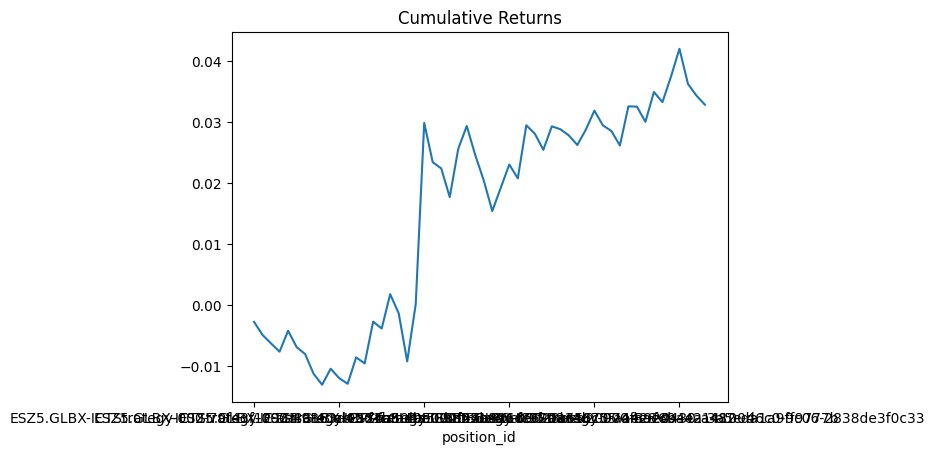

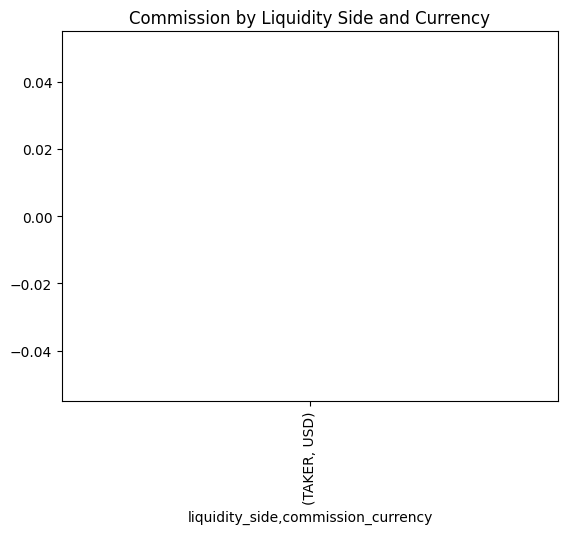

In [37]:
import matplotlib.pyplot as plt

positions_report = backtest_engine.trader.generate_positions_report()

if len(positions_report) > 0:
    # Plot cumulative returns
    returns = positions_report["realized_return"].cumsum()
    returns.plot(title="Cumulative Returns")
    plt.show()

    # Analyze fill quality (commission is a Money string e.g. "0.50 USD")
    # Extract numeric values and currency
    fills_report["commission_value"] = fills_report["commission"].str.split().str[0].astype(float)
    fills_report["commission_currency"] = fills_report["commission"].str.split().str[1]

    # Group by liquidity side and currency
    commission_by_side = fills_report.groupby(["liquidity_side", "commission_currency"])["commission_value"].sum()
    commission_by_side.plot.bar()
    plt.title("Commission by Liquidity Side and Currency")
    plt.show()
else:
    print("No positions to report.")